In [10]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import(accuracy_score,classification_report,confusion_matrix,f1_score)
from xgboost import XGBClassifier

In [2]:
base_dir = '../input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir= base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'

val_normal_dir= base_dir+'val/NORMAL/'
val_pneumonia_dir= base_dir+'val/PNEUMONIA/'

In [3]:
train_pn = [train_pneumonia_dir+"{}".format(i) for i in os.listdir(train_pneumonia_dir)]
train_normal = [train_normal_dir+"{}".format(i) for i in os.listdir(train_normal_dir)]

test_normal = [test_normal_dir+"{}".format(i) for i in os.listdir(test_normal_dir)]
test_pn = [test_pneumonia_dir+"{}".format(i) for i in os.listdir(test_pneumonia_dir)]

val_pn = [val_pneumonia_dir+"{}".format(i) for i in os.listdir(val_pneumonia_dir)]
val_normal = [val_normal_dir+"{}".format(i) for i in os.listdir(val_normal_dir)]

print("Total images:", len(train_pn+train_normal+test_normal+test_pn+val_pn+val_normal))
print("Total pneumonia images:", len(train_pn+test_pn+val_pn))
print("Total normal images:", len(train_normal+test_normal+val_normal))

pn = train_pn + test_pn + val_pn
normal = train_normal + test_normal + val_normal


#Train Test Split and Validation
train_imgs = pn[:3418] + normal[:1224]

test_imgs = pn[3418:4059] + normal[1224:1502]

val_imgs = pn[4059:] + normal[1502:]

print("Total Train Images:", len(train_imgs))
print("Total Test Images:", len(test_imgs))
print("Total Validation Images:", len(val_imgs))

# Shuffle dataset
random.shuffle(train_imgs)
random.shuffle(test_imgs)
random.shuffle(val_imgs)



Total images: 5856
Total pneumonia images: 4273
Total normal images: 1583
Total Train Images: 4642
Total Test Images: 919
Total Validation Images: 295


In [4]:
#Image Preprocessing
IMG_SIZE = 128

def preprocess_image(img_path):

    # Read image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize image
    img = img / 255.0

    # Flatten image for XGBoost
    img = img.flatten()

    return img


In [5]:
#Features and Labels
def create_dataset(img_list):

    X = []
    y = []

    for img_path in tqdm(img_list):

        try:
            img = preprocess_image(img_path)

            X.append(img)

            # Label assignment
            if 'PNEUMONIA' in img_path:
                y.append(1)
            else:
                y.append(0)

        except:
            pass

    return np.array(X), np.array(y)


In [6]:
#data preparation
print("\nProcessing Training Data...")
X_train, y_train = create_dataset(train_imgs)

print("\nProcessing Testing Data...")
X_test, y_test = create_dataset(test_imgs)

print("\nProcessing Validation Data...")
X_val, y_val = create_dataset(val_imgs)

print("\nDataset Shapes")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("X_val   :", X_val.shape)


Processing Training Data...


100%|██████████| 4642/4642 [01:46<00:00, 43.55it/s]



Processing Testing Data...


100%|██████████| 919/919 [00:17<00:00, 52.31it/s]



Processing Validation Data...


100%|██████████| 295/295 [00:04<00:00, 61.42it/s]


Dataset Shapes
X_train : (4642, 16384)
X_test  : (919, 16384)
X_val   : (295, 16384)


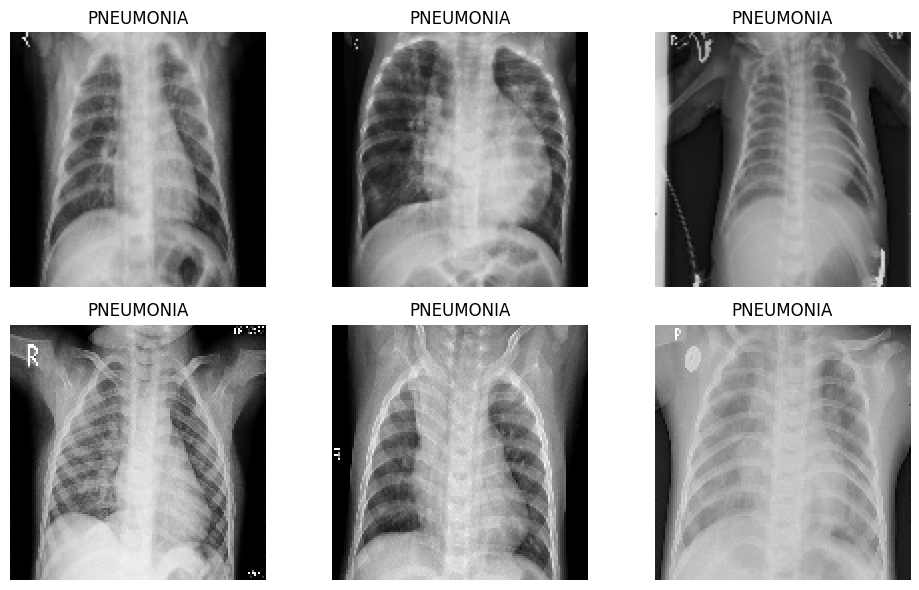

In [7]:
#Sample Image Display
plt.figure(figsize=(10,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = X_train[i].reshape(IMG_SIZE, IMG_SIZE)

    plt.imshow(img, cmap='gray')

    if y_train[i] == 1:
        plt.title("PNEUMONIA")
    else:
        plt.title("NORMAL")

    plt.axis("off")

plt.tight_layout()
plt.show()


In [11]:
#XG Boost 
xgb_model = XGBClassifier(

    n_estimators = 100,
    max_depth = 6,
    learning_rate = 0.1,

    subsample = 0.8,
    colsample_bytree = 0.8,

    objective = 'binary:logistic',

    eval_metric = 'logloss',

    random_state = 42
)

In [12]:
print("\nTraining XGBoost Model...\n")

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

# Sensitivity (Recall)
sensitivity = TP / (TP + FN)

# Specificity
specificity = TN / (TN + FP)


Training XGBoost Model...



In [14]:
print("\n===================================================")
print("            XGBOOST PERFORMANCE")
print("===================================================\n")

print(f"Accuracy    : {accuracy*100:.2f}%")
print(f"F1-Score    : {f1:.4f}")
print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")

print("\n===================================================")
print("Classification Report")
print("===================================================\n")

print(classification_report(y_test, y_pred))

print("\n===================================================")
print("Confusion Matrix")
print("===================================================\n")

print(cm)


            XGBOOST PERFORMANCE

Accuracy    : 85.64%
F1-Score    : 0.9057
Sensitivity : 0.9891
Specificity : 0.5504

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.55      0.70       278
           1       0.84      0.99      0.91       641

    accuracy                           0.86       919
   macro avg       0.90      0.77      0.80       919
weighted avg       0.87      0.86      0.84       919


Confusion Matrix

[[153 125]
 [  7 634]]


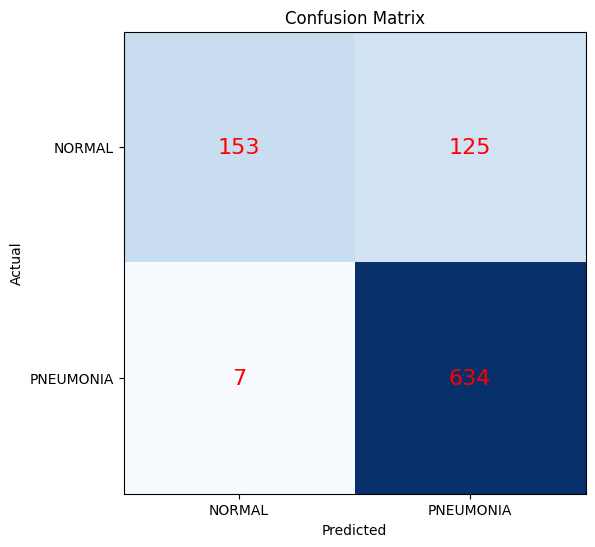

In [15]:
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xticks([0,1], ['NORMAL','PNEUMONIA'])
plt.yticks([0,1], ['NORMAL','PNEUMONIA'])

for i in range(2):
    for j in range(2):

        plt.text(j, i, cm[i,j],
                 ha='center',
                 va='center',
                 color='red',
                 fontsize=16)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
val_pred = xgb_model.predict(X_val)

val_accuracy = accuracy_score(y_val, val_pred)

print(f"\nValidation Accuracy : {val_accuracy*100:.2f}%")



Validation Accuracy : 80.00%
